In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
@load "combined_dfs.jld2" combined_dfs
@load "metrics_combined.jld2" metrics_combined
@load "dc_delta.jld2" dc_delta

1-element Vector{Symbol}:
 :dc_delta

In [20]:
function simulate_OU(k, D, dt, T, r0)
    nsteps = Int(T/dt)
    r = zeros(nsteps)
    r[1] = r0

    for i in 2:nsteps
        ξ = randn()
        # Standard OU step
        r[i] = r[i-1] - k * r[i-1] * dt + sqrt(2 * D * dt) * ξ
        
        # OPTIONAL: If you strictly need non-negative distance, 
        # use reflection or a softer boundary, not a hard clamp to 0.
        # For now, let's remove the clamp to see the true OU behavior.
        # If r represents displacement, negative values are fine.
        # If r MUST be distance, consider a Bessel process or |r|.
        # r[i] = abs(r[i]) 
    end

    return r
end

function run_simulations_and_get_means(dc_delta, metrics_combined, n_agents=1000, dt=0.01, T=600)
    results = []

    for i in 1:nrow(dc_delta)
        row = dc_delta[i, :]
        v = row[:v]
        lambda = row[:lambda]
        Dc = row[:Dc]
        delta = row[:delta]

        l = sqrt(mean(Dc) / mean(delta))
        r0 = l * 2.5 

        mask = (metrics_combined.v .== v) .& (metrics_combined.lambda .== lambda)
        
        k_x = metrics_combined.k_x[mask]
        k_y = metrics_combined.k_y[mask]
        k = mean((k_x + k_y) / 2) *10

        sigma_x = metrics_combined.sigma_x[mask]
        sigma_y = metrics_combined.sigma_y[mask]
        sigma = mean((sigma_x + sigma_y) / 2)

        # CORRECTED FORMULA: Variance = D / k  =>  D = sigma^2 * k
        D = sigma^2 * k 

        # Generate 500 trajectories (or n_agents)
        trajectory_sum = zeros(Int(T/dt))

        for agent in 1:n_agents
            traj = simulate_OU(k, D, dt, T, r0)
            trajectory_sum .+= traj
        end

        mean_1 = trajectory_sum / n_agents

        push!(results, Dict(
            :v => v,
            :lambda => lambda,
            :Dc => Dc,
            :delta => delta,
            :k => k,
            :D => D,
            :r0 => r0,
            :mean => mean_1
        ))
    end
   
    df_means = DataFrame(results)
    return df_means
end

run_simulations_and_get_means (generic function with 4 methods)

In [21]:
mean_traj = run_simulations_and_get_means(dc_delta, metrics_combined)

Row,lambda,mean,k,v,D,Dc,delta,r0
,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,0.25,"[158.114, 158.089, 158.069, 158.044, 158.02, 157.997, 157.978, 157.954, 157.935, 157.915 … 0.0806488, 0.0803033, 0.0877897, 0.0929316, 0.0914624, 0.0861717, 0.0845299, 0.0899137, 0.0885348, 0.0883444]",0.0138444,5,0.885378,40.0,0.01,158.114
2,0.5,"[79.0569, 79.0335, 79.015, 79.0044, 78.9902, 78.9656, 78.9496, 78.9297, 78.9068, 78.8879 … -0.256343, -0.252355, -0.260431, -0.266323, -0.26651, -0.261052, -0.263868, -0.257706, -0.258322, -0.263054]",0.0249453,5,1.06297,20.0,0.02,79.0569
3,0.75,"[52.698, 52.6883, 52.672, 52.6594, 52.6459, 52.6342, 52.6189, 52.5972, 52.5755, 52.5629 … 0.00975594, 0.00589585, 0.00641945, 0.00960191, 0.0115444, 0.0125176, 0.0103287, 0.00776776, 0.00744292, 0.0138987]",0.0321178,5,1.18981,13.33,0.03,52.698
4,1.0,"[39.5285, 39.5045, 39.4925, 39.4831, 39.4607, 39.4449, 39.4297, 39.4249, 39.4103, 39.399 … -0.111807, -0.117736, -0.120521, -0.118019, -0.117787, -0.115538, -0.113057, -0.103426, -0.0946342, -0.0844333]",0.0357539,5,1.27819,10.0,0.04,39.5285
5,2.0,"[19.7642, 19.7656, 19.7575, 19.7498, 19.7487, 19.7367, 19.7244, 19.7218, 19.7056, 19.6926 … -0.264463, -0.262202, -0.258264, -0.251028, -0.246712, -0.252957, -0.249605, -0.24748, -0.249221, -0.252657]",0.0385313,5,1.54134,5.0,0.08,19.7642
6,3.0,"[13.1762, 13.1665, 13.1649, 13.1611, 13.1535, 13.146, 13.1322, 13.1306, 13.1264, 13.1216 … -0.241937, -0.232437, -0.224094, -0.223969, -0.226193, -0.224934, -0.217595, -0.215508, -0.216279, -0.21429]",0.0365666,5,1.50754,3.33333,0.12,13.1762
7,4.0,"[9.88212, 9.87449, 9.8728, 9.87574, 9.87548, 9.86619, 9.87659, 9.86991, 9.86277, 9.85868 … -0.0884618, -0.083337, -0.0719233, -0.0720319, -0.0706094, -0.0638842, -0.073465, -0.0808835, -0.0731399, -0.0705845]",0.0363378,5,1.4033,2.5,0.16,9.88212
8,5.0,"[7.90569, 7.9055, 7.90195, 7.89662, 7.88722, 7.89468, 7.88579, 7.88461, 7.88432, 7.88488 … -0.137744, -0.139249, -0.127091, -0.121922, -0.117723, -0.11632, -0.116462, -0.115181, -0.111553, -0.109972]",0.0378552,5,1.82536,2.0,0.2,7.90569
9,6.0,"[6.58808, 6.58344, 6.57878, 6.56877, 6.56152, 6.56099, 6.56263, 6.55127, 6.55248, 6.55165 … 0.503471, 0.499557, 0.497, 0.50127, 0.494455, 0.491725, 0.497448, 0.504855, 0.492119, 0.480891]",0.0383565,5,2.34556,1.66667,0.24,6.58808


In [30]:
df = combined_dfs[(20.0, 0.25)]
grouped = groupby(df, :step)
mean(grouped[1].x)

631.8021688807576

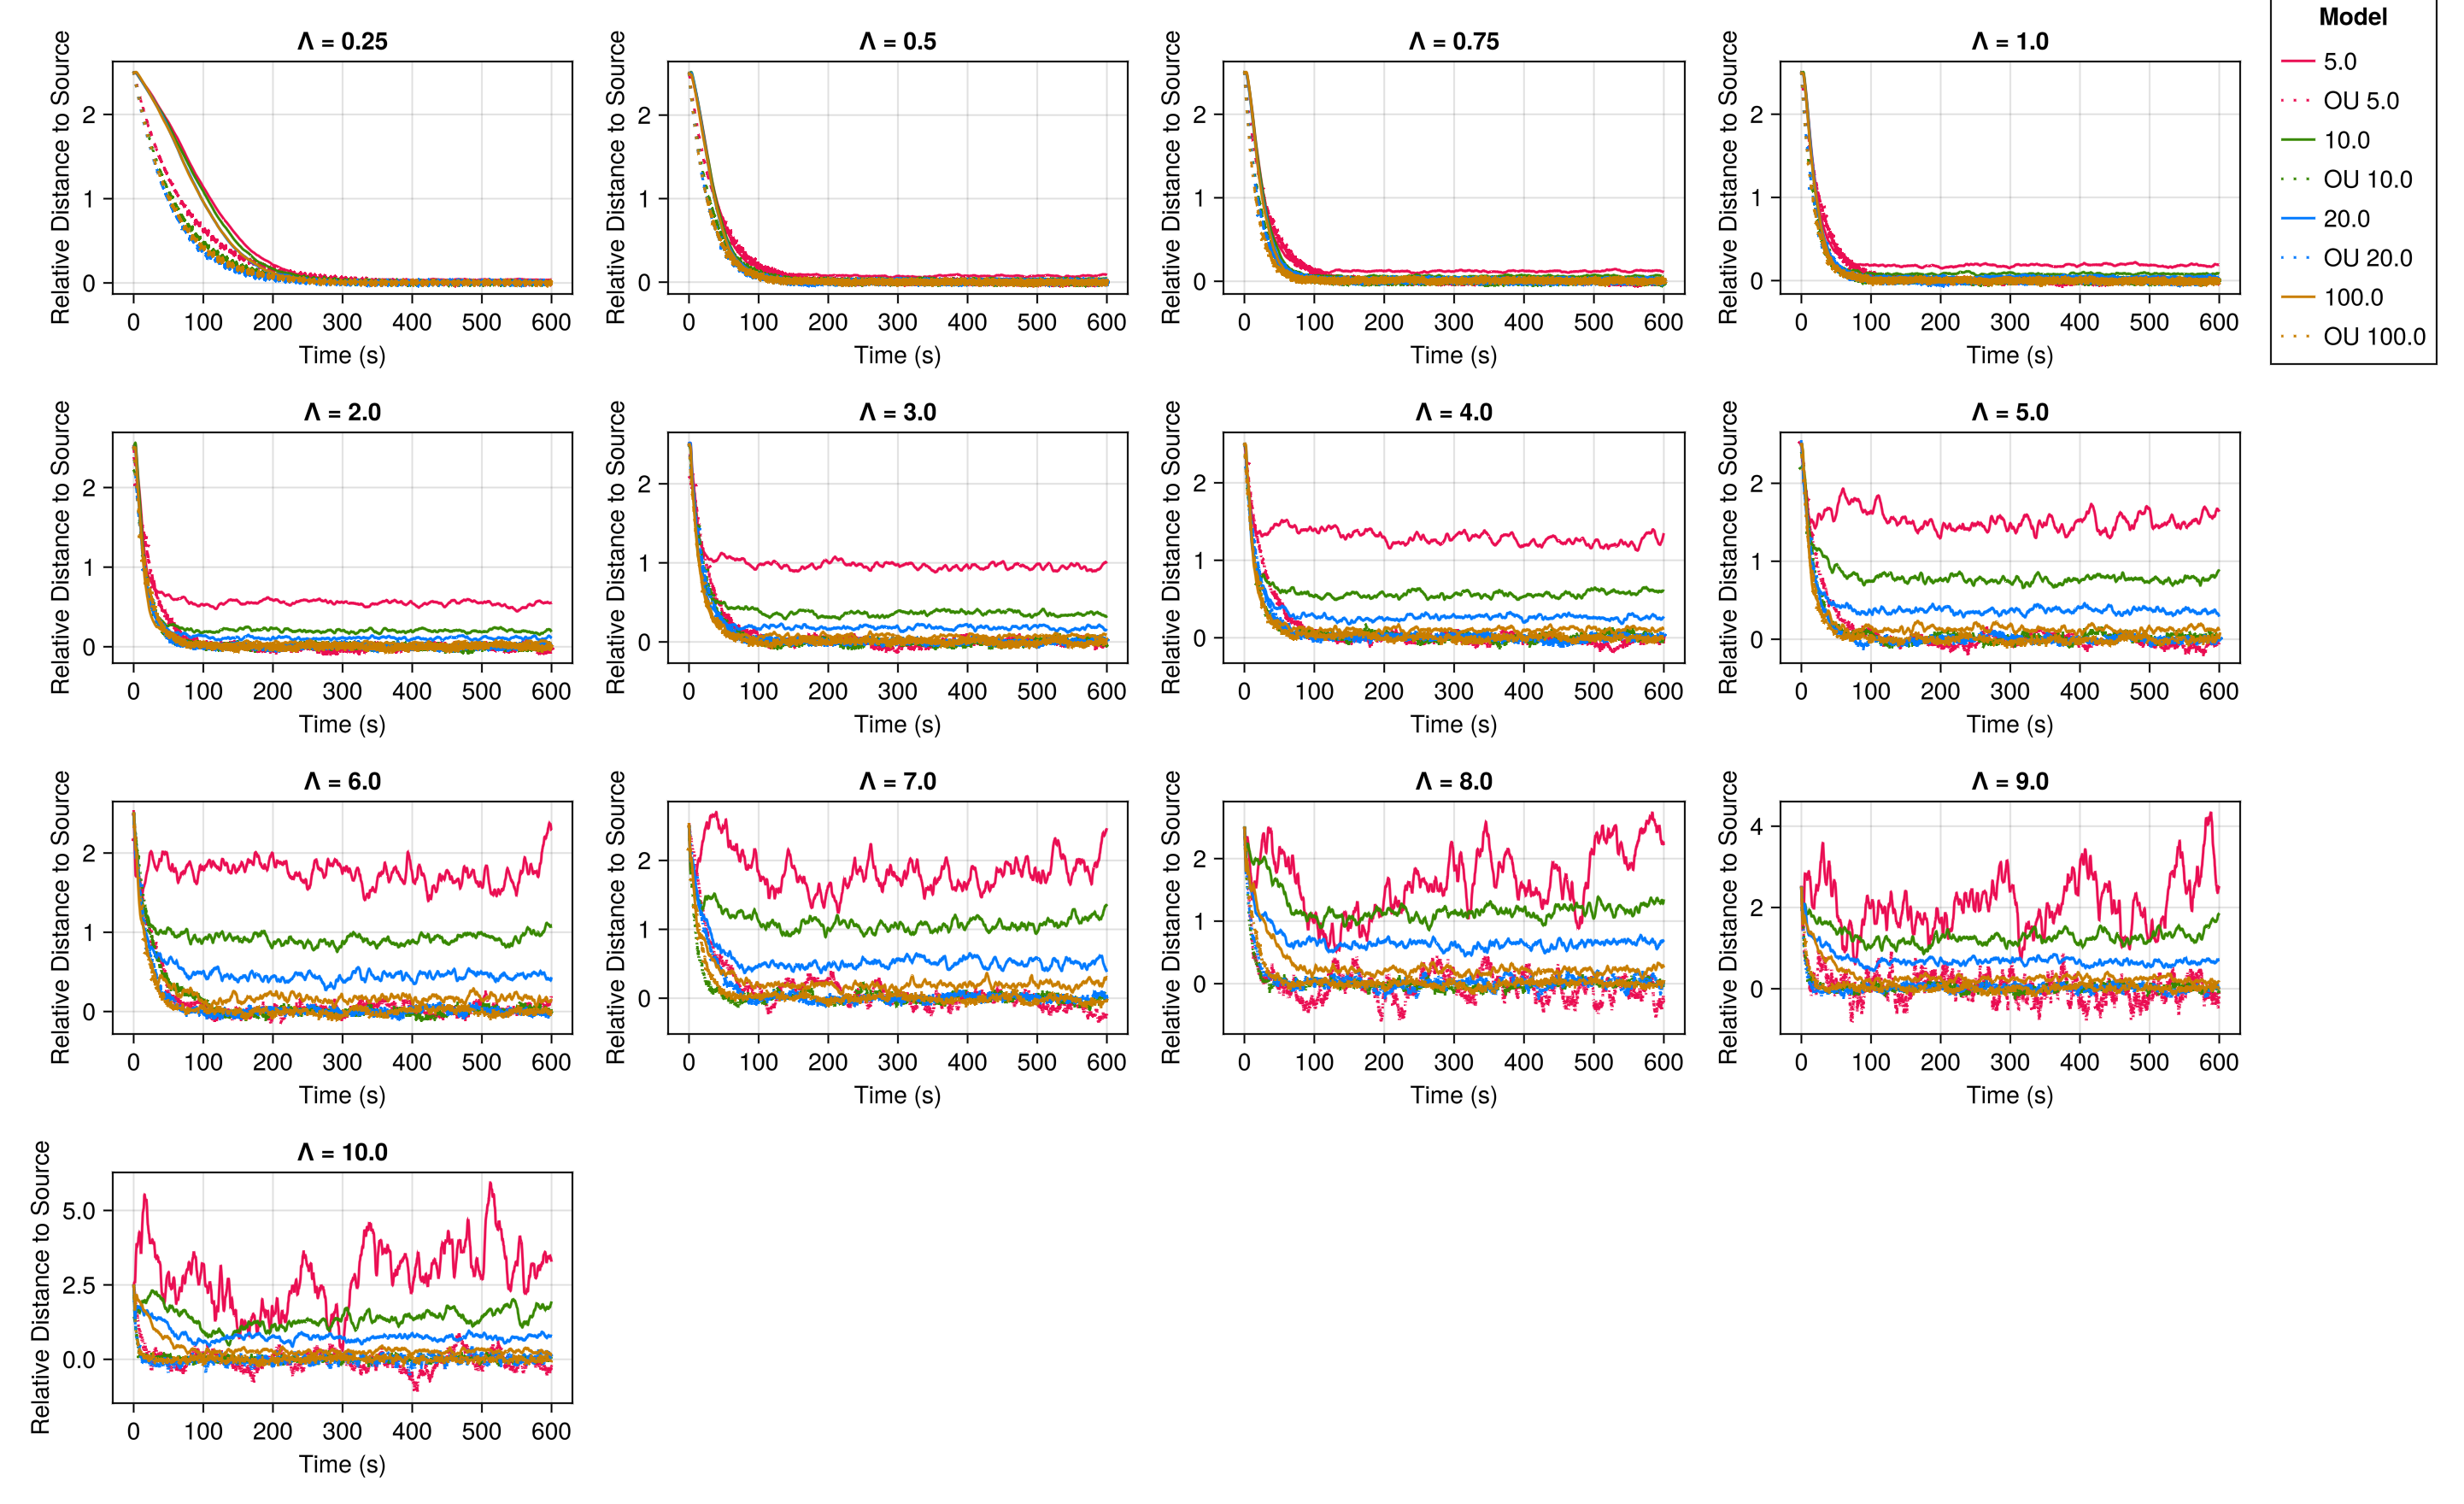

GLMakie.Screen(...)

In [8]:
# lambdas = [0.25, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]
# velocities = [5.0]
# velocities = [10.0]
# velocities = [20.0]
# velocities = [100.0]
thresholds = [40, 75, 275, 850]
# thresholds = [40]
# thresholds = [75]
# thresholds = [275]
# thresholds = [850]

# colors = distinguishable_colors(4, [RGB(1,1, 1), RGB(0, 0, 0)], dropseed = true, lchoices=range(70, stop=95, length = 15), cchoices=range(10, stop=40, length=15))
colors = distinguishable_colors(
    4,
    [RGB(1,1,1), RGB(0,0,0)],
    dropseed = true,
    lchoices = range(50, stop=85, length=20),
    cchoices = range(30, stop=80, length=20)
)
id_to_color = Dict(1:4 .=> colors)
# colors = [
#     RGB(0.0, 0.45, 0.70),   # blue
#     RGB(0.90, 0.60, 0.0),   # orange
#     RGB(0.0, 0.60, 0.50),   # bluish green
#     RGB(0.80, 0.40, 0.0)    # vermillion
# ]

# colors = [:red, :blue, :green, :yellow]
# colors_2 = [:pink, :black, :brown, :orange]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = combined_dfs[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        # l = sqrt(Dc/delta)
        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        eq = grouped[3000:end]
        df_subset = DataFrame(eq)

        if lambda < 6.0

            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        else
            t = (thresholds[v_idx])/2
            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        end

        bad_agents = unique(df_subset[bad_rows_mask, :agent])

        df_clean = filter(row -> !(row.agent in bad_agents), df)

        if isempty(df_clean)
            @warn "No data for v=$v, lambda=$lambda. Skipping."
            continue
        end

        grouped_t = groupby(df_clean, :step)
        
        if isempty(grouped_t)
             @warn "No steps found in filtered data."
             continue
        end


        for i in 1:length(grouped_t)
            data_1 = grouped_t[i]
            x = data_1.x ./l
            y = data_1.y ./l

            # r = sqrt.(data_1.x .^ 2 .+ data_1.y .^ 2)
            # rl = r ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj.lambda .== lambda) .& (mean_traj.v .== v) 

        mean_OU = mean_traj.mean[mask]
        mean_OUl = mean_OU ./ l 
        flat_vec = vcat(mean_OUl...)
        
        lines!(ax_x, (1:length(grouped_t))*0.1, mean_x, color = id_to_color[v_idx], label = "$v")
        lines!(ax_x, (1:length(flat_vec))*0.01, flat_vec, color = id_to_color[v_idx], linestyle = (:dot, :loose), label = "OU $v")


        if idx == 13 & v_idx == 4
            fig2[:,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)

In [9]:
save("Plots/Fixed_source_model/OU/OU_all_colors.png", fig2)

In [42]:
@save "mean_traj_OU.jld2" mean_traj

In [5]:
@load "mean_traj_OU.jld2" mean_traj

1-element Vector{Symbol}:
 :mean_traj